### Logistic regression: classify gender based on head size and brain weight
1. Load data: all data points
2. Initialize random weights, Calculate gradient
3. Update weights through gradient descent
4. Predict

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("brain_dataset.csv")

X = data[["Head Size(cm^3)", "Brain Weight(grams)"]].values
y_raw = data[["Gender"]].values
y = (y_raw == y_raw.max()).astype(float)  # ensure labels are 0/1

X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True)
X_std[X_std == 0] = 1.0
X_norm = (X - X_mean) / X_std #needed otherwise loss goes up 

n_samples = X_norm.shape[0]
X_bias = np.hstack([np.ones((n_samples, 1)), X_norm])

print(f"Loaded {n_samples} samples with labels in {np.unique(y).ravel()}")
data.head()

Loaded 237 samples with labels in [0. 1.]


,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_pred):
    eps = 1e-9
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def train_logistic_regression(X, y, lr, epochs):
    rng = np.random.default_rng(seed=42)
    weights = rng.normal(loc=0.0, scale=0.1, size=(X.shape[1], 1))
    losses = []
    steps = []
    for i in range(epochs):
        # fwd pass
        z = X @ weights
        y_hat = sigmoid(z)

        # Gradient: (1/n) * X^T (y_hat - y)
        error = y_hat - y
        grad = X.T @ error / X.shape[0]

        weights -= lr * grad

        if i == 0 or (i + 1) % 200 == 0:
            losses.append(compute_loss(y, y_hat))
            steps.append(i + 1)
    return weights, losses, steps

weights, losses, steps = train_logistic_regression(X_bias, y, lr=0.1, epochs=500)

print(f"loss: {losses[-1]:.4f}")

loss: 0.5238


Accurac: 72.15%


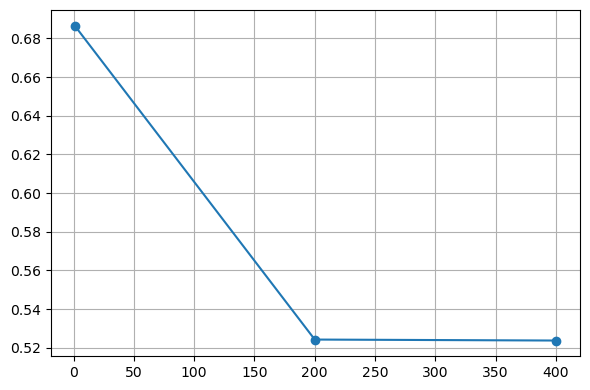

In [17]:
y_prob = sigmoid(X_bias @ weights)
y_pred = (y_prob >= 0.5).astype(int)

accuracy = (y_pred == y).mean()
print(f"Accurac: {accuracy * 100:.2f}%")

plt.figure(figsize=(6, 4))
plt.plot(steps, losses, marker="o")
plt.grid(True)
plt.tight_layout()
plt.show()